In [3]:
print("Hospital Appointment System")
print("Python is working!")

Hospital Appointment System
Python is working!


In [4]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [5]:
negative_waiting[
    [
        "PatientId",
        "AppointmentID",
        "ScheduledDay",
        "AppointmentDay",
        "Waiting_Days"
    ]
]

NameError: name 'negative_waiting' is not defined

In [ ]:
import pandas as pd

file_path = "../data/KaggleV2-May-2016.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 110527
Number of columns: 14


In [ ]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.6 MB


In [ ]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [ ]:
df_clean["Waiting_Days_Clean"] = df_clean["Waiting_Days"].clip(lower=0)

print(df_clean["Waiting_Days_Clean"].describe())

count    110527.000000
mean         10.183792
std          15.254924
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: Waiting_Days_Clean, dtype: float64


In [ ]:
print("Negative values before cleaning:", (df_clean["Waiting_Days"] < 0).sum())
print("Negative values after cleaning:", (df_clean["Waiting_Days_Clean"] < 0).sum())

Negative values before cleaning: 5


KeyError: 'Waiting_Days_Clean'

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df_clean = df.copy()

print("Working copy created.")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Working copy created.
Rows: 110527
Columns: 14


In [ ]:
df_clean = df_clean.rename(columns={
    "Hipertension": "Hypertension",
    "No-show": "No_Show"
})

print(df_clean.columns.tolist())

['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No_Show']


In [ ]:
df_clean["ScheduledDay"] = pd.to_datetime(df_clean["ScheduledDay"], utc=True)
df_clean["AppointmentDay"] = pd.to_datetime(df_clean["AppointmentDay"], utc=True)

print(df_clean[["ScheduledDay", "AppointmentDay"]].dtypes)

ScheduledDay      datetime64[us, UTC]
AppointmentDay    datetime64[us, UTC]
dtype: object


In [ ]:
df_clean["Waiting_Days"] = (
    df_clean["AppointmentDay"].dt.normalize()
    - df_clean["ScheduledDay"].dt.normalize()
).dt.days

print(df_clean["Waiting_Days"].describe())

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: Waiting_Days, dtype: float64


In [ ]:
negative_waiting = df_clean[df_clean["Waiting_Days"] < 0]

print("Records with negative waiting days:", len(negative_waiting))

Records with negative waiting days: 5


In [ ]:
df_clean["Appointment_Year"] = df_clean["AppointmentDay"].dt.year
df_clean["Appointment_Month"] = df_clean["AppointmentDay"].dt.month
df_clean["Appointment_Day"] = df_clean["AppointmentDay"].dt.day
df_clean["Appointment_Weekday"] = df_clean["AppointmentDay"].dt.dayofweek

print(
    df_clean[
        [
            "AppointmentDay",
            "Appointment_Year",
            "Appointment_Month",
            "Appointment_Day",
            "Appointment_Weekday"
        ]
    ].head()
)

             AppointmentDay  Appointment_Year  Appointment_Month  \
0 2016-04-29 00:00:00+00:00              2016                  4   
1 2016-04-29 00:00:00+00:00              2016                  4   
2 2016-04-29 00:00:00+00:00              2016                  4   
3 2016-04-29 00:00:00+00:00              2016                  4   
4 2016-04-29 00:00:00+00:00              2016                  4   

   Appointment_Day  Appointment_Weekday  
0               29                    4  
1               29                    4  
2               29                    4  
3               29                    4  
4               29                    4  


In [ ]:
df_clean["Scheduled_Hour"] = df_clean["ScheduledDay"].dt.hour

print(df_clean["Scheduled_Hour"].value_counts().sort_index())

Scheduled_Hour
6      1578
7     19213
8     15349
9     12823
10    11056
11     8462
12     5422
13     9036
14     9127
15     8079
16     5542
17     2909
18     1340
19      488
20      100
21        3
Name: count, dtype: int64


In [ ]:
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[-1, 17, 30, 45, 60, 120],
    labels=["0-17", "18-30", "31-45", "46-60", "61+"]
)

print(df_clean["Age_Group"].value_counts().sort_index())

Age_Group
0-17     27379
18-30    18252
31-45    21954
46-60    23179
61+      19762
Name: count, dtype: int64


In [ ]:
print("Original columns:", df.shape[1])
print("Cleaned columns:", df_clean.shape[1])

Original columns: 14
Cleaned columns: 21


In [ ]:
df_clean.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,...,Handcap,SMS_received,No_Show,Waiting_Days,Appointment_Year,Appointment_Month,Appointment_Day,Appointment_Weekday,Scheduled_Hour,Age_Group
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,...,0,0,No,0,2016,4,29,4,18,61+
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,...,0,0,No,0,2016,4,29,4,16,46-60
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,...,0,0,No,0,2016,4,29,4,16,61+
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,...,0,0,No,0,2016,4,29,4,17,0-17
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,...,0,0,No,0,2016,4,29,4,16,46-60


In [ ]:
df_clean["Waiting_Days_Clean"] = df_clean["Waiting_Days"].clip(lower=0)

print(df_clean["Waiting_Days_Clean"].describe())

count    110527.000000
mean         10.183792
std          15.254924
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: Waiting_Days_Clean, dtype: float64


In [ ]:
print("Negative values before cleaning:", (df_clean["Waiting_Days"] < 0).sum())
print("Negative values after cleaning:", (df_clean["Waiting_Days_Clean"] < 0).sum())

Negative values before cleaning: 5
Negative values after cleaning: 0


In [ ]:
print(df_clean["Age"].describe())

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64


In [ ]:
print("Age less than 0:", (df_clean["Age"] < 0).sum())
print("Age greater than 100:", (df_clean["Age"] > 100).sum())

Age less than 0: 1
Age greater than 100: 7


In [ ]:
unusual_age = df_clean[
    (df_clean["Age"] < 0) | (df_clean["Age"] > 100)
]

unusual_age[
    [
        "PatientId",
        "AppointmentID",
        "Gender",
        "Age",
        "Neighbourhood",
        "ScheduledDay",
        "AppointmentDay",
        "No_Show"
    ]
]

,PatientId,AppointmentID,Gender,Age,Neighbourhood,ScheduledDay,AppointmentDay,No_Show
58014,9.762948e+14,5651757,F,102,CONQUISTA,2016-05-03 09:14:53+00:00,2016-05-03 00:00:00+00:00,No
63912,3.196321e+13,5700278,F,115,ANDORINHAS,2016-05-16 09:17:44+00:00,2016-05-19 00:00:00+00:00,Yes
63915,3.196321e+13,5700279,F,115,ANDORINHAS,2016-05-16 09:17:44+00:00,2016-05-19 00:00:00+00:00,Yes
68127,3.196321e+13,5562812,F,115,ANDORINHAS,2016-04-08 14:29:17+00:00,2016-05-16 00:00:00+00:00,Yes
76284,3.196321e+13,5744037,F,115,ANDORINHAS,2016-05-30 09:44:51+00:00,2016-05-30 00:00:00+00:00,No
90372,2.342836e+11,5751563,F,102,MARIA ORTIZ,2016-05-31 10:19:49+00:00,2016-06-02 00:00:00+00:00,No
97666,7.482346e+14,5717451,F,115,SÃO JOSÉ,2016-05-19 07:57:56+00:00,2016-06-03 00:00:00+00:00,No
99832,4.659432e+14,5775010,F,-1,ROMÃO,2016-06-06 08:58:13+00:00,2016-06-06 00:00:00+00:00,No


In [ ]:
df_clean["Age_Clean"] = df_clean["Age"].replace(-1, pd.NA)

print("Invalid ages before cleaning:", (df_clean["Age"] < 0).sum())
print("Missing ages after cleaning:", df_clean["Age_Clean"].isna().sum())

Invalid ages before cleaning: 1
Missing ages after cleaning: 1


In [ ]:
print(df_clean["Age_Clean"].describe())

count     110526
unique       103
top            0
freq        3539
Name: Age_Clean, dtype: int64


In [ ]:
df_clean["Age_Clean"] = pd.to_numeric(df_clean["Age_Clean"], errors="coerce")

print(df_clean["Age_Clean"].describe())

count    110526.000000
mean         37.089219
std          23.110026
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age_Clean, dtype: float64


In [ ]:
print("Missing values in Age_Clean:", df_clean["Age_Clean"].isna().sum())
print("Minimum age:", df_clean["Age_Clean"].min())
print("Maximum age:", df_clean["Age_Clean"].max())

Missing values in Age_Clean: 1
Minimum age: 0.0
Maximum age: 115.0


In [ ]:
print(df_clean["No_Show"].value_counts())

No_Show
No     88208
Yes    22319
Name: count, dtype: int64


In [ ]:
print(df_clean["No_Show"].value_counts(normalize=True) * 100)

No_Show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


In [ ]:
print("Unique No_Show values:")
print(df_clean["No_Show"].unique())

Unique No_Show values:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [ ]:
df_clean["Attendance_Status"] = df_clean["No_Show"].map({
    "No": "Attended",
    "Yes": "No-Show"
})

print(df_clean["Attendance_Status"].value_counts())

Attendance_Status
Attended    88208
No-Show     22319
Name: count, dtype: int64


In [ ]:
df_clean["No_Show_Target"] = df_clean["No_Show"].map({
    "No": 0,
    "Yes": 1
})

print(df_clean["No_Show_Target"].value_counts())

No_Show_Target
0    88208
1    22319
Name: count, dtype: int64


In [ ]:
attendance_summary = df_clean["Attendance_Status"].value_counts()

print(attendance_summary)

Attendance_Status
Attended    88208
No-Show     22319
Name: count, dtype: int64


In [ ]:
attendance_percentage = (
    df_clean["Attendance_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(attendance_percentage)

Attendance_Status
Attended    79.81
No-Show     20.19
Name: proportion, dtype: float64


In [ ]:
weekday_summary = df_clean.groupby("Appointment_Weekday").agg(
    Total_Appointments=("AppointmentID", "count"),
    No_Shows=("No_Show_Target", "sum")
)

weekday_summary["No_Show_Rate"] = (
    weekday_summary["No_Shows"] /
    weekday_summary["Total_Appointments"] * 100
).round(2)

print(weekday_summary)

                     Total_Appointments  No_Shows  No_Show_Rate
Appointment_Weekday                                            
0                                 22715      4690         20.65
1                                 25640      5152         20.09
2                                 25867      5093         19.69
3                                 17247      3338         19.35
4                                 19019      4037         21.23
5                                    39         9         23.08


In [ ]:
weekday_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

weekday_summary.index = weekday_summary.index.map(weekday_names)

print(weekday_summary)

                     Total_Appointments  No_Shows  No_Show_Rate
Appointment_Weekday                                            
Monday                            22715      4690         20.65
Tuesday                           25640      5152         20.09
Wednesday                         25867      5093         19.69
Thursday                          17247      3338         19.35
Friday                            19019      4037         21.23
Saturday                             39         9         23.08


In [ ]:
monthly_summary = df_clean.groupby("Appointment_Month").agg(
    Total_Appointments=("AppointmentID", "count"),
    No_Shows=("No_Show_Target", "sum")
)

monthly_summary["No_Show_Rate"] = (
    monthly_summary["No_Shows"] /
    monthly_summary["Total_Appointments"] * 100
).round(2)

print(monthly_summary)

                   Total_Appointments  No_Shows  No_Show_Rate
Appointment_Month                                            
4                                3235       633         19.57
5                               80841     16804         20.79
6                               26451      4882         18.46


In [ ]:
month_names = {
    4: "April",
    5: "May",
    6: "June"
}

monthly_summary.index = monthly_summary.index.map(month_names)

print(monthly_summary)

                   Total_Appointments  No_Shows  No_Show_Rate
Appointment_Month                                            
April                            3235       633         19.57
May                             80841     16804         20.79
June                            26451      4882         18.46


In [ ]:
waiting_summary = df_clean.groupby("No_Show").agg(
    Average_Waiting_Days=("Waiting_Days_Clean", "mean"),
    Median_Waiting_Days=("Waiting_Days_Clean", "median"),
    Appointment_Count=("AppointmentID", "count")
)

print(waiting_summary.round(2))

         Average_Waiting_Days  Median_Waiting_Days  Appointment_Count
No_Show                                                              
No                       8.75                  2.0              88208
Yes                     15.83                 11.0              22319


In [ ]:
waiting_summary_status = df_clean.groupby("Attendance_Status").agg(
    Average_Waiting_Days=("Waiting_Days_Clean", "mean"),
    Median_Waiting_Days=("Waiting_Days_Clean", "median"),
    Appointment_Count=("AppointmentID", "count")
)

print(waiting_summary_status.round(2))

                   Average_Waiting_Days  Median_Waiting_Days  \
Attendance_Status                                              
Attended                           8.75                  2.0   
No-Show                           15.83                 11.0   

                   Appointment_Count  
Attendance_Status                     
Attended                       88208  
No-Show                        22319  


In [ ]:
sms_summary = df_clean.groupby("SMS_received").agg(
    Total_Appointments=("AppointmentID", "count"),
    No_Shows=("No_Show_Target", "sum")
)

sms_summary["No_Show_Rate"] = (
    sms_summary["No_Shows"] /
    sms_summary["Total_Appointments"] * 100
).round(2)

print(sms_summary)

              Total_Appointments  No_Shows  No_Show_Rate
SMS_received                                            
0                          75045     12535         16.70
1                          35482      9784         27.57


In [ ]:
sms_summary.index = sms_summary.index.map({
    0: "No SMS",
    1: "SMS Received"
})

print(sms_summary)

              Total_Appointments  No_Shows  No_Show_Rate
SMS_received                                            
No SMS                     75045     12535         16.70
SMS Received               35482      9784         27.57


In [ ]:
age_summary = df_clean.groupby("Age_Group", observed=True).agg(
    Total_Appointments=("AppointmentID", "count"),
    No_Shows=("No_Show_Target", "sum")
)

age_summary["No_Show_Rate"] = (
    age_summary["No_Shows"] /
    age_summary["Total_Appointments"] * 100
).round(2)

print(age_summary)

           Total_Appointments  No_Shows  No_Show_Rate
Age_Group                                            
0-17                    27379      5997         21.90
18-30                   18252      4493         24.62
31-45                   21954      4692         21.37
46-60                   23179      4131         17.82
61+                     19762      3006         15.21


In [ ]:
print(age_summary.sort_values("No_Show_Rate", ascending=False))

           Total_Appointments  No_Shows  No_Show_Rate
Age_Group                                            
18-30                   18252      4493         24.62
0-17                    27379      5997         21.90
31-45                   21954      4692         21.37
46-60                   23179      4131         17.82
61+                     19762      3006         15.21


In [ ]:
health_features = [
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handcap"
]

for feature in health_features:
    health_summary = df_clean.groupby(feature).agg(
        Total_Appointments=("AppointmentID", "count"),
        No_Shows=("No_Show_Target", "sum")
    )

    health_summary["No_Show_Rate"] = (
        health_summary["No_Shows"] /
        health_summary["Total_Appointments"] * 100
    ).round(2)

    print("\n", feature)
    print(health_summary)


 Hypertension
              Total_Appointments  No_Shows  No_Show_Rate
Hypertension                                            
0                          88726     18547          20.9
1                          21801      3772          17.3

 Diabetes
          Total_Appointments  No_Shows  No_Show_Rate
Diabetes                                            
0                     102584     20889         20.36
1                       7943      1430         18.00

 Alcoholism
            Total_Appointments  No_Shows  No_Show_Rate
Alcoholism                                            
0                       107167     21642         20.19
1                         3360       677         20.15

 Handcap
         Total_Appointments  No_Shows  No_Show_Rate
Handcap                                            
0                    108286     21912         20.24
1                      2042       366         17.92
2                       183        37         20.22
3                        13    

In [ ]:
neighbourhood_summary = df_clean.groupby("Neighbourhood").agg(
    Total_Appointments=("AppointmentID", "count"),
    No_Shows=("No_Show_Target", "sum")
)

neighbourhood_summary["No_Show_Rate"] = (
    neighbourhood_summary["No_Shows"] /
    neighbourhood_summary["Total_Appointments"] * 100
).round(2)

neighbourhood_summary = neighbourhood_summary[
    neighbourhood_summary["Total_Appointments"] >= 500
]

print("Neighbourhoods with at least 500 appointments:")
print(neighbourhood_summary.sort_values(
    "Total_Appointments",
    ascending=False
).head(15))

Neighbourhoods with at least 500 appointments:
                   Total_Appointments  No_Shows  No_Show_Rate
Neighbourhood                                                
JARDIM CAMBURI                   7717      1465         18.98
MARIA ORTIZ                      5805      1219         21.00
RESISTÊNCIA                      4431       906         20.45
JARDIM DA PENHA                  3877       631         16.28
ITARARÉ                          3514       923         26.27
CENTRO                           3334       703         21.09
TABUAZEIRO                       3132       573         18.30
SANTA MARTHA                     3131       496         15.84
JESUS DE NAZARETH                2853       696         24.40
BONFIM                           2773       550         19.83
SANTO ANTÔNIO                    2746       484         17.63
SANTO ANDRÉ                      2571       508         19.76
CARATOÍRA                        2565       591         23.04
JABOUR                 

In [ ]:
hour_summary = df_clean.groupby("Scheduled_Hour").agg(
    Total_Appointments=("AppointmentID", "count"),
    No_Shows=("No_Show_Target", "sum")
)

hour_summary["No_Show_Rate"] = (
    hour_summary["No_Shows"] /
    hour_summary["Total_Appointments"] * 100
).round(2)

print(hour_summary)

                Total_Appointments  No_Shows  No_Show_Rate
Scheduled_Hour                                            
6                             1578       303         19.20
7                            19213      2911         15.15
8                            15349      2804         18.27
9                            12823      2526         19.70
10                           11056      2440         22.07
11                            8462      1928         22.78
12                            5422      1104         20.36
13                            9036      1891         20.93
14                            9127      2070         22.68
15                            8079      1873         23.18
16                            5542      1317         23.76
17                            2909       722         24.82
18                            1340       285         21.27
19                             488       114         23.36
20                             100        30         30.

In [ ]:
print("\nSorted by No-Show Rate:")
print(hour_summary.sort_values("No_Show_Rate", ascending=False))


Sorted by No-Show Rate:
                Total_Appointments  No_Shows  No_Show_Rate
Scheduled_Hour                                            
21                               3         1         33.33
20                             100        30         30.00
17                            2909       722         24.82
16                            5542      1317         23.76
19                             488       114         23.36
15                            8079      1873         23.18
11                            8462      1928         22.78
14                            9127      2070         22.68
10                           11056      2440         22.07
18                            1340       285         21.27
13                            9036      1891         20.93
12                            5422      1104         20.36
9                            12823      2526         19.70
6                             1578       303         19.20
8                            15

In [ ]:
waiting_bins = [-1, 0, 7, 14, 30, 60, float("inf")]
waiting_labels = [
    "Same Day",
    "1-7 Days",
    "8-14 Days",
    "15-30 Days",
    "31-60 Days",
    "61+ Days"
]

df_clean["Waiting_Group"] = pd.cut(
    df_clean["Waiting_Days_Clean"],
    bins=waiting_bins,
    labels=waiting_labels
)

waiting_group_summary = df_clean.groupby(
    "Waiting_Group",
    observed=True
).agg(
    Total_Appointments=("AppointmentID", "count"),
    No_Shows=("No_Show_Target", "sum")
)

waiting_group_summary["No_Show_Rate"] = (
    waiting_group_summary["No_Shows"] /
    waiting_group_summary["Total_Appointments"] * 100
).round(2)

print(waiting_group_summary)

               Total_Appointments  No_Shows  No_Show_Rate
Waiting_Group                                            
Same Day                    38568      1797          4.66
1-7 Days                    32185      7772         24.15
8-14 Days                   12025      3664         30.47
15-30 Days                  17371      5661         32.59
31-60 Days                   8283      2829         34.15
61+ Days                     2095       596         28.45


In [ ]:
print("\nSorted by No-Show Rate:")
print(
    waiting_group_summary.sort_values(
        "No_Show_Rate",
        ascending=False
    )
)


Sorted by No-Show Rate:
               Total_Appointments  No_Shows  No_Show_Rate
Waiting_Group                                            
31-60 Days                   8283      2829         34.15
15-30 Days                  17371      5661         32.59
8-14 Days                   12025      3664         30.47
61+ Days                     2095       596         28.45
1-7 Days                    32185      7772         24.15
Same Day                    38568      1797          4.66


In [ ]:
print("Current columns in df_clean:")
for i, column in enumerate(df_clean.columns, start=1):
    print(i, "-", column)

Current columns in df_clean:
1 - PatientId
2 - AppointmentID
3 - Gender
4 - ScheduledDay
5 - AppointmentDay
6 - Age
7 - Neighbourhood
8 - Scholarship
9 - Hypertension
10 - Diabetes
11 - Alcoholism
12 - Handcap
13 - SMS_received
14 - No_Show
15 - Waiting_Days
16 - Appointment_Year
17 - Appointment_Month
18 - Appointment_Day
19 - Appointment_Weekday
20 - Scheduled_Hour
21 - Age_Group
22 - Waiting_Days_Clean
23 - Age_Clean
24 - Attendance_Status
25 - No_Show_Target
26 - Waiting_Group


In [ ]:
print("\nDataset shape:", df_clean.shape)


Dataset shape: (110527, 26)


In [ ]:
ml_features = [
    "Gender",
    "Age_Clean",
    "Neighbourhood",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "Waiting_Days_Clean",
    "Appointment_Weekday",
    "Appointment_Month",
    "Scheduled_Hour"
]

target = "No_Show_Target"

ml_df = df_clean[ml_features + [target]].copy()

print("ML dataset created successfully!")
print("Rows:", ml_df.shape[0])
print("Columns:", ml_df.shape[1])
print("\nML columns:")
print(ml_df.columns.tolist())

ML dataset created successfully!
Rows: 110527
Columns: 14

ML columns:
['Gender', 'Age_Clean', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'Waiting_Days_Clean', 'Appointment_Weekday', 'Appointment_Month', 'Scheduled_Hour', 'No_Show_Target']


In [ ]:
print("\nMissing values in ML dataset:")
print(ml_df.isnull().sum())


Missing values in ML dataset:
Gender                 0
Age_Clean              1
Neighbourhood          0
Scholarship            0
Hypertension           0
Diabetes               0
Alcoholism             0
Handcap                0
SMS_received           0
Waiting_Days_Clean     0
Appointment_Weekday    0
Appointment_Month      0
Scheduled_Hour         0
No_Show_Target         0
dtype: int64


In [ ]:
median_age = ml_df["Age_Clean"].median()

ml_df["Age_Clean"] = ml_df["Age_Clean"].fillna(median_age)

print("Median age used:", median_age)
print("Missing Age_Clean values after cleaning:",
      ml_df["Age_Clean"].isnull().sum())

Median age used: 37.0
Missing Age_Clean values after cleaning: 0


In [ ]:
print("Final ML dataset shape:", ml_df.shape)
print("\nMissing values:")
print(ml_df.isnull().sum())

Final ML dataset shape: (110527, 14)

Missing values:
Gender                 0
Age_Clean              0
Neighbourhood          0
Scholarship            0
Hypertension           0
Diabetes               0
Alcoholism             0
Handcap                0
SMS_received           0
Waiting_Days_Clean     0
Appointment_Weekday    0
Appointment_Month      0
Scheduled_Hour         0
No_Show_Target         0
dtype: int64


In [ ]:
X = ml_df.drop("No_Show_Target", axis=1)
y = ml_df["No_Show_Target"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (110527, 13)
Target (y): (110527,)


In [ ]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
No_Show_Target
0    88208
1    22319
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (88421, 13)
Testing features: (22106, 13)
Training target: (88421,)
Testing target: (22106,)


In [ ]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training target distribution:
No_Show_Target
0    79.81
1    20.19
Name: proportion, dtype: float64

Testing target distribution:
No_Show_Target
0    79.81
1    20.19
Name: proportion, dtype: float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Gender",
    "Neighbourhood"
]

numerical_features = [
    "Age_Clean",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "Waiting_Days_Clean",
    "Appointment_Weekday",
    "Appointment_Month",
    "Scheduled_Hour"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nTotal features:",
      len(categorical_features) + len(numerical_features))

Categorical features:
['Gender', 'Neighbourhood']

Numerical features:
['Age_Clean', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'Waiting_Days_Clean', 'Appointment_Weekday', 'Appointment_Month', 'Scheduled_Hour']

Total features: 13


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [ ]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 22106


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation")
print("----------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Model Evaluation
----------------
Accuracy : 0.6567
Precision: 0.3156
Recall   : 0.5992
F1-Score : 0.4134
ROC-AUC  : 0.6739


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Attended", "No-Show"]
))

              precision    recall  f1-score   support

    Attended       0.87      0.67      0.76     17642
     No-Show       0.32      0.60      0.41      4464

    accuracy                           0.66     22106
   macro avg       0.59      0.64      0.59     22106
weighted avg       0.76      0.66      0.69     22106



Confusion Matrix:
[[11841  5801]
 [ 1789  2675]]


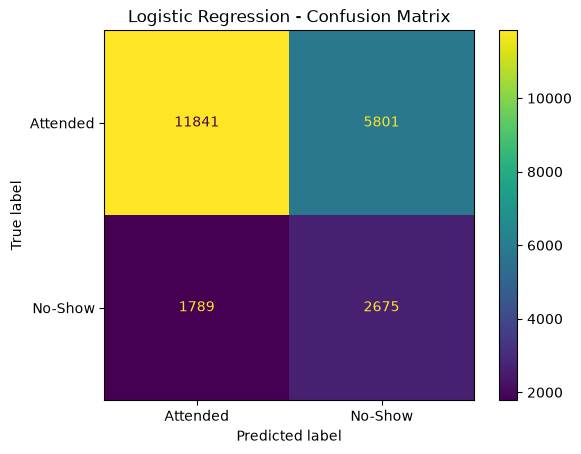

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Attended", "No-Show"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

NameError: name 'preprocessor' is not defined

In [ ]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
rf_y_pred = random_forest_model.predict(X_test)
rf_y_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(rf_y_pred))

Random Forest predictions generated successfully!
Number of predictions: 22106


In [ ]:
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_prob)

print("Random Forest Evaluation")
print("------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Evaluation
------------------------
Accuracy : 0.753
Precision: 0.39
Recall   : 0.3954
F1-Score : 0.3927
ROC-AUC  : 0.741


In [ ]:
print(classification_report(
    y_test,
    rf_y_pred,
    target_names=["Attended", "No-Show"]
))

              precision    recall  f1-score   support

    Attended       0.85      0.84      0.84     17642
     No-Show       0.39      0.40      0.39      4464

    accuracy                           0.75     22106
   macro avg       0.62      0.62      0.62     22106
weighted avg       0.75      0.75      0.75     22106



Random Forest Confusion Matrix:
[[14881  2761]
 [ 2699  1765]]


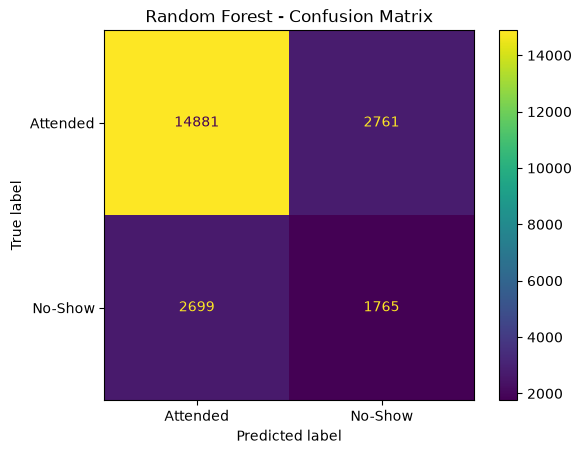

In [ ]:
rf_cm = confusion_matrix(y_test, rf_y_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Attended", "No-Show"]
)

rf_disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
import numpy as np

threshold = 0.40

rf_y_pred_40 = (rf_y_prob >= threshold).astype(int)

print("Random Forest with threshold =", threshold)
print("Accuracy :", round(accuracy_score(y_test, rf_y_pred_40), 4))
print("Precision:", round(precision_score(y_test, rf_y_pred_40), 4))
print("Recall   :", round(recall_score(y_test, rf_y_pred_40), 4))
print("F1-Score :", round(f1_score(y_test, rf_y_pred_40), 4))

Random Forest with threshold = 0.4
Accuracy : 0.6923
Precision: 0.3481
Recall   : 0.6001
F1-Score : 0.4406


In [ ]:
print(classification_report(
    y_test,
    rf_y_pred_40,
    target_names=["Attended", "No-Show"]
))

              precision    recall  f1-score   support

    Attended       0.88      0.72      0.79     17642
     No-Show       0.35      0.60      0.44      4464

    accuracy                           0.69     22106
   macro avg       0.61      0.66      0.61     22106
weighted avg       0.77      0.69      0.72     22106



In [ ]:
threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:
    predictions = (rf_y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4))

   Threshold  Accuracy  Precision  Recall  F1-Score
0       0.30    0.6139     0.3171  0.7905    0.4526
1       0.35    0.6538     0.3311  0.7003    0.4496
2       0.40    0.6923     0.3481  0.6001    0.4406
3       0.45    0.7251     0.3677  0.5022    0.4246
4       0.50    0.7521     0.3900  0.4039    0.3968


In [ ]:
print("\nBest threshold by F1-Score:")
print(
    threshold_df.loc[
        threshold_df["F1-Score"].idxmax()
    ].round(4)
)


Best threshold by F1-Score:
Threshold    0.3000
Accuracy     0.6139
Precision    0.3171
Recall       0.7905
F1-Score     0.4526
Name: 0, dtype: float64


In [ ]:
final_threshold = 0.30

final_y_pred = (rf_y_prob >= final_threshold).astype(int)

print("Final Threshold:", final_threshold)
print("Accuracy :", round(accuracy_score(y_test, final_y_pred), 4))
print("Precision:", round(precision_score(y_test, final_y_pred), 4))
print("Recall   :", round(recall_score(y_test, final_y_pred), 4))
print("F1-Score :", round(f1_score(y_test, final_y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_y_prob), 4))

Final Threshold: 0.3
Accuracy : 0.6139
Precision: 0.3171
Recall   : 0.7905
F1-Score : 0.4526
ROC-AUC  : 0.741


In [ ]:
final_cm = confusion_matrix(y_test, final_y_pred)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[10041  7601]
 [  935  3529]]


In [ ]:
import joblib

model_data = {
    "model": random_forest_model,
    "threshold": final_threshold
}

joblib.dump(
    model_data,
    "../models/no_show_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [ ]:
import os

model_path = "../models/no_show_model.pkl"

print("Model file exists:", os.path.exists(model_path))
print("Model path:", model_path)

Model file exists: True
Model path: ../models/no_show_model.pkl


In [ ]:
hospital_config = pd.DataFrame({
    "Department": [
        "General Medicine",
        "Cardiology",
        "Orthopedics",
        "Pediatrics",
        "Dermatology"
    ],
    "Doctors": [
        5,
        3,
        4,
        3,
        2
    ],
    "Slots_Per_Doctor": [
        20,
        15,
        15,
        18,
        15
    ]
})

hospital_config["Daily_Capacity"] = (
    hospital_config["Doctors"] *
    hospital_config["Slots_Per_Doctor"]
)

print(hospital_config)

         Department  Doctors  Slots_Per_Doctor  Daily_Capacity
0  General Medicine        5                20             100
1        Cardiology        3                15              45
2       Orthopedics        4                15              60
3        Pediatrics        3                18              54
4       Dermatology        2                15              30


In [ ]:
hospital_config.to_csv("../data/hospital_config.csv", index=False)

print("Hospital configuration saved successfully.")

Hospital configuration saved successfully.


In [ ]:
total_daily_capacity = hospital_config["Daily_Capacity"].sum()

print("Total Hospital Daily Capacity:", total_daily_capacity)

Total Hospital Daily Capacity: 289


In [ ]:
department_capacity = hospital_config[
    ["Department", "Doctors", "Slots_Per_Doctor", "Daily_Capacity"]
].copy()

print(department_capacity)

         Department  Doctors  Slots_Per_Doctor  Daily_Capacity
0  General Medicine        5                20             100
1        Cardiology        3                15              45
2       Orthopedics        4                15              60
3        Pediatrics        3                18              54
4       Dermatology        2                15              30


In [ ]:
daily_demand = (
    df_clean.groupby("AppointmentDay")
    .size()
    .reset_index(name="Appointments")
)

print(daily_demand.head(10))

             AppointmentDay  Appointments
0 2016-04-29 00:00:00+00:00          3235
1 2016-05-02 00:00:00+00:00          4376
2 2016-05-03 00:00:00+00:00          4256
3 2016-05-04 00:00:00+00:00          4168
4 2016-05-05 00:00:00+00:00          4273
5 2016-05-06 00:00:00+00:00          3879
6 2016-05-09 00:00:00+00:00          4520
7 2016-05-10 00:00:00+00:00          4308
8 2016-05-11 00:00:00+00:00          4474
9 2016-05-12 00:00:00+00:00          4394


In [ ]:
average_daily_demand = daily_demand["Appointments"].mean()

daily_demand["Demand_Index"] = (
    daily_demand["Appointments"] / average_daily_demand
)

print("Average Historical Daily Demand:", round(average_daily_demand, 2))
print(daily_demand.head(10))

Average Historical Daily Demand: 4093.59
             AppointmentDay  Appointments  Demand_Index
0 2016-04-29 00:00:00+00:00          3235      0.790259
1 2016-05-02 00:00:00+00:00          4376      1.068988
2 2016-05-03 00:00:00+00:00          4256      1.039674
3 2016-05-04 00:00:00+00:00          4168      1.018177
4 2016-05-05 00:00:00+00:00          4273      1.043826
5 2016-05-06 00:00:00+00:00          3879      0.947578
6 2016-05-09 00:00:00+00:00          4520      1.104165
7 2016-05-10 00:00:00+00:00          4308      1.052376
8 2016-05-11 00:00:00+00:00          4474      1.092928
9 2016-05-12 00:00:00+00:00          4394      1.073385


In [ ]:
simulated_capacity = total_daily_capacity

daily_demand["Estimated_Hospital_Demand"] = (
    daily_demand["Demand_Index"] * simulated_capacity
).round().astype(int)

daily_demand["Capacity_Utilization"] = (
    daily_demand["Estimated_Hospital_Demand"] / simulated_capacity * 100
).round(2)

print(daily_demand.head(10))

             AppointmentDay  Appointments  Demand_Index  \
0 2016-04-29 00:00:00+00:00          3235      0.790259   
1 2016-05-02 00:00:00+00:00          4376      1.068988   
2 2016-05-03 00:00:00+00:00          4256      1.039674   
3 2016-05-04 00:00:00+00:00          4168      1.018177   
4 2016-05-05 00:00:00+00:00          4273      1.043826   
5 2016-05-06 00:00:00+00:00          3879      0.947578   
6 2016-05-09 00:00:00+00:00          4520      1.104165   
7 2016-05-10 00:00:00+00:00          4308      1.052376   
8 2016-05-11 00:00:00+00:00          4474      1.092928   
9 2016-05-12 00:00:00+00:00          4394      1.073385   

   Estimated_Hospital_Demand  Capacity_Utilization  
0                        228                 78.89  
1                        309                106.92  
2                        300                103.81  
3                        294                101.73  
4                        302                104.50  
5                        274    

In [ ]:
def classify_capacity(utilization):
    if utilization < 70:
        return "Low"
    elif utilization < 90:
        return "Normal"
    elif utilization <= 100:
        return "High"
    else:
        return "Over Capacity"


daily_demand["Capacity_Status"] = (
    daily_demand["Capacity_Utilization"]
    .apply(classify_capacity)
)

print(
    daily_demand[
        [
            "AppointmentDay",
            "Estimated_Hospital_Demand",
            "Capacity_Utilization",
            "Capacity_Status"
        ]
    ].head(10)
)

             AppointmentDay  Estimated_Hospital_Demand  Capacity_Utilization  \
0 2016-04-29 00:00:00+00:00                        228                 78.89   
1 2016-05-02 00:00:00+00:00                        309                106.92   
2 2016-05-03 00:00:00+00:00                        300                103.81   
3 2016-05-04 00:00:00+00:00                        294                101.73   
4 2016-05-05 00:00:00+00:00                        302                104.50   
5 2016-05-06 00:00:00+00:00                        274                 94.81   
6 2016-05-09 00:00:00+00:00                        319                110.38   
7 2016-05-10 00:00:00+00:00                        304                105.19   
8 2016-05-11 00:00:00+00:00                        316                109.34   
9 2016-05-12 00:00:00+00:00                        310                107.27   

  Capacity_Status  
0          Normal  
1   Over Capacity  
2   Over Capacity  
3   Over Capacity  
4   Over Capacity  

In [ ]:
capacity_summary = (
    daily_demand["Capacity_Status"]
    .value_counts()
    .rename_axis("Capacity_Status")
    .reset_index(name="Number_of_Days")
)

print(capacity_summary)

  Capacity_Status  Number_of_Days
0   Over Capacity              19
1            High               6
2          Normal               1
3             Low               1


In [ ]:
capacity_summary["Percentage_of_Days"] = (
    capacity_summary["Number_of_Days"]
    / capacity_summary["Number_of_Days"].sum()
    * 100
).round(2)

print(capacity_summary)

  Capacity_Status  Number_of_Days  Percentage_of_Days
0   Over Capacity              19               70.37
1            High               6               22.22
2          Normal               1                3.70
3             Low               1                3.70


In [ ]:
hospital_config["Capacity_Share"] = (
    hospital_config["Daily_Capacity"]
    / hospital_config["Daily_Capacity"].sum()
    * 100
).round(2)

print(
    hospital_config[
        ["Department", "Daily_Capacity", "Capacity_Share"]
    ]
)

         Department  Daily_Capacity  Capacity_Share
0  General Medicine             100           34.60
1        Cardiology              45           15.57
2       Orthopedics              60           20.76
3        Pediatrics              54           18.69
4       Dermatology              30           10.38


In [ ]:
department_demand = hospital_config[
    ["Department", "Daily_Capacity", "Capacity_Share"]
].copy()

average_hospital_demand = daily_demand["Estimated_Hospital_Demand"].mean()

department_demand["Estimated_Daily_Demand"] = (
    department_demand["Capacity_Share"] / 100
    * average_hospital_demand
).round().astype(int)

department_demand["Estimated_Utilization"] = (
    department_demand["Estimated_Daily_Demand"]
    / department_demand["Daily_Capacity"]
    * 100
).round(2)

print(department_demand)

         Department  Daily_Capacity  Capacity_Share  Estimated_Daily_Demand  \
0  General Medicine             100           34.60                     100   
1        Cardiology              45           15.57                      45   
2       Orthopedics              60           20.76                      60   
3        Pediatrics              54           18.69                      54   
4       Dermatology              30           10.38                      30   

   Estimated_Utilization  
0                  100.0  
1                  100.0  
2                  100.0  
3                  100.0  
4                  100.0  


In [ ]:
demand_weights = {
    "General Medicine": 1.20,
    "Cardiology": 0.80,
    "Orthopedics": 1.10,
    "Pediatrics": 0.90,
    "Dermatology": 0.65
}

department_demand["Demand_Weight"] = (
    department_demand["Department"].map(demand_weights)
)

department_demand["Weighted_Demand"] = (
    department_demand["Daily_Capacity"]
    * department_demand["Demand_Weight"]
)

total_weighted_demand = department_demand["Weighted_Demand"].sum()

department_demand["Estimated_Daily_Demand"] = (
    department_demand["Weighted_Demand"]
    / total_weighted_demand
    * average_hospital_demand
).round().astype(int)

department_demand["Estimated_Utilization"] = (
    department_demand["Estimated_Daily_Demand"]
    / department_demand["Daily_Capacity"]
    * 100
).round(2)

print(
    department_demand[
        [
            "Department",
            "Daily_Capacity",
            "Estimated_Daily_Demand",
            "Estimated_Utilization"
        ]
    ]
)

         Department  Daily_Capacity  Estimated_Daily_Demand  \
0  General Medicine             100                     120   
1        Cardiology              45                      36   
2       Orthopedics              60                      66   
3        Pediatrics              54                      48   
4       Dermatology              30                      19   

   Estimated_Utilization  
0                 120.00  
1                  80.00  
2                 110.00  
3                  88.89  
4                  63.33  


In [ ]:
department_demand["Spare_Capacity"] = (
    department_demand["Daily_Capacity"]
    - department_demand["Estimated_Daily_Demand"]
)

department_demand["Capacity_Status"] = (
    department_demand["Estimated_Utilization"]
    .apply(classify_capacity)
)

print(
    department_demand[
        [
            "Department",
            "Daily_Capacity",
            "Estimated_Daily_Demand",
            "Spare_Capacity",
            "Estimated_Utilization",
            "Capacity_Status"
        ]
    ]
)

         Department  Daily_Capacity  Estimated_Daily_Demand  Spare_Capacity  \
0  General Medicine             100                     120             -20   
1        Cardiology              45                      36               9   
2       Orthopedics              60                      66              -6   
3        Pediatrics              54                      48               6   
4       Dermatology              30                      19              11   

   Estimated_Utilization Capacity_Status  
0                 120.00   Over Capacity  
1                  80.00          Normal  
2                 110.00   Over Capacity  
3                  88.89          Normal  
4                  63.33             Low  


In [ ]:
def capacity_recommendation(row):
    if row["Spare_Capacity"] < 0:
        return "Consider additional slots or capacity reallocation"
    elif row["Spare_Capacity"] == 0:
        return "Capacity fully utilized"
    elif row["Estimated_Utilization"] >= 85:
        return "Monitor capacity closely"
    else:
        return "Capacity available"

department_demand["Recommendation"] = department_demand.apply(
    capacity_recommendation,
    axis=1
)

print(
    department_demand[
        [
            "Department",
            "Daily_Capacity",
            "Estimated_Daily_Demand",
            "Spare_Capacity",
            "Estimated_Utilization",
            "Capacity_Status",
            "Recommendation"
        ]
    ]
)

         Department  Daily_Capacity  Estimated_Daily_Demand  Spare_Capacity  \
0  General Medicine             100                     120             -20   
1        Cardiology              45                      36               9   
2       Orthopedics              60                      66              -6   
3        Pediatrics              54                      48               6   
4       Dermatology              30                      19              11   

   Estimated_Utilization Capacity_Status  \
0                 120.00   Over Capacity   
1                  80.00          Normal   
2                 110.00   Over Capacity   
3                  88.89          Normal   
4                  63.33             Low   

                                      Recommendation  
0  Consider additional slots or capacity realloca...  
1                                 Capacity available  
2  Consider additional slots or capacity realloca...  
3                           Monitor capa

In [ ]:
slot_data = []

for _, row in hospital_config.iterrows():
    department = row["Department"]
    doctors = row["Doctors"]
    slots_per_doctor = row["Slots_Per_Doctor"]

    for doctor in range(1, doctors + 1):
        for slot in range(1, slots_per_doctor + 1):
            slot_data.append({
                "Department": department,
                "Doctor": f"Doctor {doctor}",
                "Slot_Number": slot
            })

available_slots = pd.DataFrame(slot_data)

print(available_slots.head(20))
print("\nTotal simulated slots:", len(available_slots))

          Department    Doctor  Slot_Number
0   General Medicine  Doctor 1            1
1   General Medicine  Doctor 1            2
2   General Medicine  Doctor 1            3
3   General Medicine  Doctor 1            4
4   General Medicine  Doctor 1            5
5   General Medicine  Doctor 1            6
6   General Medicine  Doctor 1            7
7   General Medicine  Doctor 1            8
8   General Medicine  Doctor 1            9
9   General Medicine  Doctor 1           10
10  General Medicine  Doctor 1           11
11  General Medicine  Doctor 1           12
12  General Medicine  Doctor 1           13
13  General Medicine  Doctor 1           14
14  General Medicine  Doctor 1           15
15  General Medicine  Doctor 1           16
16  General Medicine  Doctor 1           17
17  General Medicine  Doctor 1           18
18  General Medicine  Doctor 1           19
19  General Medicine  Doctor 1           20

Total simulated slots: 289


In [ ]:
from datetime import datetime, timedelta

slot_data = []

for _, row in hospital_config.iterrows():
    department = row["Department"]
    doctors = row["Doctors"]
    slots_per_doctor = row["Slots_Per_Doctor"]

    for doctor in range(1, doctors + 1):
        start_time = datetime.strptime("09:00", "%H:%M")

        for slot in range(1, slots_per_doctor + 1):
            appointment_time = start_time + timedelta(minutes=(slot - 1) * 30)

            slot_data.append({
                "Department": department,
                "Doctor": f"Doctor {doctor}",
                "Slot_Number": slot,
                "Appointment_Time": appointment_time.strftime("%I:%M %p")
            })

available_slots = pd.DataFrame(slot_data)

print(available_slots.head(20))
print("\nTotal simulated slots:", len(available_slots))

          Department    Doctor  Slot_Number Appointment_Time
0   General Medicine  Doctor 1            1         09:00 AM
1   General Medicine  Doctor 1            2         09:30 AM
2   General Medicine  Doctor 1            3         10:00 AM
3   General Medicine  Doctor 1            4         10:30 AM
4   General Medicine  Doctor 1            5         11:00 AM
5   General Medicine  Doctor 1            6         11:30 AM
6   General Medicine  Doctor 1            7         12:00 PM
7   General Medicine  Doctor 1            8         12:30 PM
8   General Medicine  Doctor 1            9         01:00 PM
9   General Medicine  Doctor 1           10         01:30 PM
10  General Medicine  Doctor 1           11         02:00 PM
11  General Medicine  Doctor 1           12         02:30 PM
12  General Medicine  Doctor 1           13         03:00 PM
13  General Medicine  Doctor 1           14         03:30 PM
14  General Medicine  Doctor 1           15         04:00 PM
15  General Medicine  Do

In [ ]:
available_departments = department_demand[
    department_demand["Spare_Capacity"] > 0
].copy()

print(
    available_departments[
        [
            "Department",
            "Daily_Capacity",
            "Estimated_Daily_Demand",
            "Spare_Capacity",
            "Estimated_Utilization",
            "Capacity_Status"
        ]
    ]
)

    Department  Daily_Capacity  Estimated_Daily_Demand  Spare_Capacity  \
1   Cardiology              45                      36               9   
3   Pediatrics              54                      48               6   
4  Dermatology              30                      19              11   

   Estimated_Utilization Capacity_Status  
1                  80.00          Normal  
3                  88.89          Normal  
4                  63.33             Low  


In [ ]:
available_slots_filtered = available_slots[
    available_slots["Department"].isin(
        available_departments["Department"]
    )
].copy()

print(available_slots_filtered.head(20))
print("\nTotal available slots:", len(available_slots_filtered))

     Department    Doctor  Slot_Number Appointment_Time
100  Cardiology  Doctor 1            1         09:00 AM
101  Cardiology  Doctor 1            2         09:30 AM
102  Cardiology  Doctor 1            3         10:00 AM
103  Cardiology  Doctor 1            4         10:30 AM
104  Cardiology  Doctor 1            5         11:00 AM
105  Cardiology  Doctor 1            6         11:30 AM
106  Cardiology  Doctor 1            7         12:00 PM
107  Cardiology  Doctor 1            8         12:30 PM
108  Cardiology  Doctor 1            9         01:00 PM
109  Cardiology  Doctor 1           10         01:30 PM
110  Cardiology  Doctor 1           11         02:00 PM
111  Cardiology  Doctor 1           12         02:30 PM
112  Cardiology  Doctor 1           13         03:00 PM
113  Cardiology  Doctor 1           14         03:30 PM
114  Cardiology  Doctor 1           15         04:00 PM
115  Cardiology  Doctor 2            1         09:00 AM
116  Cardiology  Doctor 2            2         0

In [ ]:
def recommend_slots(department, number_of_slots=5):
    department_slots = available_slots_filtered[
        available_slots_filtered["Department"] == department
    ].copy()

    if department_slots.empty:
        return f"No available slots for {department}."

    return department_slots.head(number_of_slots)[
        [
            "Department",
            "Doctor",
            "Slot_Number",
            "Appointment_Time"
        ]
    ]

In [ ]:
recommend_slots("Cardiology", 5)

,Department,Doctor,Slot_Number,Appointment_Time
100,Cardiology,Doctor 1,1,09:00 AM
101,Cardiology,Doctor 1,2,09:30 AM
102,Cardiology,Doctor 1,3,10:00 AM
103,Cardiology,Doctor 1,4,10:30 AM
104,Cardiology,Doctor 1,5,11:00 AM


In [ ]:
def recommend_slots(department, preferred_time="09:00 AM", number_of_slots=5):
    department_slots = available_slots_filtered[
        available_slots_filtered["Department"] == department
    ].copy()

    if department_slots.empty:
        return f"No available slots for {department}."

    department_slots["Time_Difference"] = (
        pd.to_datetime(department_slots["Appointment_Time"], format="%I:%M %p")
        - pd.to_datetime(preferred_time, format="%I:%M %p")
    ).abs()

    department_slots = department_slots.sort_values("Time_Difference")

    return department_slots.head(number_of_slots)[
        [
            "Department",
            "Doctor",
            "Slot_Number",
            "Appointment_Time"
        ]
    ]

In [ ]:
recommend_slots("Cardiology", "02:00 PM", 5)

,Department,Doctor,Slot_Number,Appointment_Time
140,Cardiology,Doctor 3,11,02:00 PM
125,Cardiology,Doctor 2,11,02:00 PM
110,Cardiology,Doctor 1,11,02:00 PM
111,Cardiology,Doctor 1,12,02:30 PM
141,Cardiology,Doctor 3,12,02:30 PM


In [ ]:
def recommend_slots(department, preferred_time="09:00 AM", number_of_slots=5):
    department_slots = available_slots_filtered[
        available_slots_filtered["Department"] == department
    ].copy()

    if department_slots.empty:
        return f"No available slots for {department}."

    preferred = pd.to_datetime(
        preferred_time,
        format="%I:%M %p"
    )

    department_slots["Appointment_Time_dt"] = pd.to_datetime(
        department_slots["Appointment_Time"],
        format="%I:%M %p"
    )

    department_slots["Time_Difference_Minutes"] = (
        department_slots["Appointment_Time_dt"] - preferred
    ).abs().dt.total_seconds() / 60

    department_slots = department_slots.sort_values(
        ["Time_Difference_Minutes", "Doctor"]
    )

    department_slots["Recommendation_Rank"] = range(
        1,
        len(department_slots) + 1
    )

    return department_slots.head(number_of_slots)[
        [
            "Recommendation_Rank",
            "Department",
            "Doctor",
            "Slot_Number",
            "Appointment_Time",
            "Time_Difference_Minutes"
        ]
    ]

In [ ]:
recommend_slots("Cardiology", "02:00 PM", 5)

,Recommendation_Rank,Department,Doctor,Slot_Number,Appointment_Time,Time_Difference_Minutes
110,1,Cardiology,Doctor 1,11,02:00 PM,0.0
125,2,Cardiology,Doctor 2,11,02:00 PM,0.0
140,3,Cardiology,Doctor 3,11,02:00 PM,0.0
109,4,Cardiology,Doctor 1,10,01:30 PM,30.0
111,5,Cardiology,Doctor 1,12,02:30 PM,30.0


In [ ]:
sample_appointment = pd.DataFrame({
    "Gender": ["F"],
    "Age_Clean": [30],
    "Neighbourhood": ["JARDIM CAMBURI"],
    "Scholarship": [0],
    "Hypertension": [0],
    "Diabetes": [0],
    "Alcoholism": [0],
    "Handcap": [0],
    "SMS_received": [0],
    "Waiting_Days_Clean": [10],
    "Appointment_Weekday": [2],
    "Appointment_Month": [5],
    "Scheduled_Hour": [10]
})

print(sample_appointment)

  Gender  Age_Clean   Neighbourhood  Scholarship  Hypertension  Diabetes  \
0      F         30  JARDIM CAMBURI            0             0         0   

   Alcoholism  Handcap  SMS_received  Waiting_Days_Clean  Appointment_Weekday  \
0           0        0             0                  10                    2   

   Appointment_Month  Scheduled_Hour  
0                  5              10  


In [ ]:
sample_probability = random_forest_model.predict_proba(
    sample_appointment
)[0][1]

print(
    "Predicted No-Show Probability:",
    round(sample_probability * 100, 2),
    "%"
)

Predicted No-Show Probability: 46.5 %


In [ ]:
def classify_no_show_risk(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"


risk_level = classify_no_show_risk(sample_probability)

print("No-Show Risk Level:", risk_level)

No-Show Risk Level: Medium Risk


In [ ]:
def appointment_recommendation(
    appointment_data,
    department,
    preferred_time="09:00 AM",
    number_of_slots=5
):
    # Predict no-show probability
    probability = random_forest_model.predict_proba(
        appointment_data
    )[0][1]

    # Classify risk
    risk = classify_no_show_risk(probability)

    # Find recommended slots
    slots = recommend_slots(
        department,
        preferred_time,
        number_of_slots
    )

    print("Appointment Recommendation")
    print("-" * 30)
    print("Department:", department)
    print("Preferred Time:", preferred_time)
    print("No-Show Probability:", round(probability * 100, 2), "%")
    print("Risk Level:", risk)
    print("\nRecommended Slots:")
    
    return slots

In [ ]:
appointment_recommendation(
    sample_appointment,
    "Cardiology",
    "02:00 PM",
    5
)

Appointment Recommendation
------------------------------
Department: Cardiology
Preferred Time: 02:00 PM
No-Show Probability: 46.5 %
Risk Level: Medium Risk

Recommended Slots:


,Recommendation_Rank,Department,Doctor,Slot_Number,Appointment_Time,Time_Difference_Minutes
110,1,Cardiology,Doctor 1,11,02:00 PM,0.0
125,2,Cardiology,Doctor 2,11,02:00 PM,0.0
140,3,Cardiology,Doctor 3,11,02:00 PM,0.0
109,4,Cardiology,Doctor 1,10,01:30 PM,30.0
111,5,Cardiology,Doctor 1,12,02:30 PM,30.0


In [ ]:
available_slots.to_csv(
    "../data/available_slots.csv",
    index=False
)

print("Available slots saved successfully.")
print("File: ../data/available_slots.csv")

Available slots saved successfully.
File: ../data/available_slots.csv


In [ ]:
import sys
sys.path.append("../src")

from scheduling import load_slot_data, recommend_slots
from prediction import load_no_show_model, predict_no_show, classify_no_show_risk

print("Modules imported successfully!")

Modules imported successfully!


In [ ]:
# Load the saved model
model, threshold = load_no_show_model()

print("No-show model loaded successfully!")
print("Final prediction threshold:", threshold)

# Load the saved appointment slots
slots = load_slot_data()

print("\nAppointment slots loaded successfully!")
print("Total slots:", len(slots))

# Show first 5 slots
slots.head()

No-show model loaded successfully!
Final prediction threshold: 0.3

Appointment slots loaded successfully!
Total slots: 289


,Department,Doctor,Slot_Number,Appointment_Time
0,General Medicine,Doctor 1,1,09:00 AM
1,General Medicine,Doctor 1,2,09:30 AM
2,General Medicine,Doctor 1,3,10:00 AM
3,General Medicine,Doctor 1,4,10:30 AM
4,General Medicine,Doctor 1,5,11:00 AM
